# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_ratio_all = df.isnull().mean().sort_values(ascending=False)

print("Tỷ lệ missing của toàn bộ dataframe:")
display(missing_ratio_all)

...

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive",
    "who",
    "adult_male",
    "class",
    "deck",
    "embark_town",
    "alone"]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
leaky = [col for col in leaky if col in df.columns]
# df = df.drop(columns=...)
df = df.drop(columns=leaky)

# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại:", list(df.columns))
display(df.head())

Tỷ lệ missing của toàn bộ dataframe:


deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
sex            0.000000
pclass         0.000000
survived       0.000000
fare           0.000000
parch          0.000000
sibsp          0.000000
class          0.000000
adult_male     0.000000
who            0.000000
alive          0.000000
alone          0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*
Nếu để lại cột `alive`, mô hình gần như sẽ đạt accuracy rất cao vì `alive` chính là cách viết khác của `survived`. Ví dụ `alive = yes` tương ứng với `survived = 1`, còn `alive = no` tương ứng với `survived = 0`.

Như vậy mô hình không thật sự học từ các đặc trưng như tuổi, giới tính, hạng vé hay giá vé, mà chỉ đang nhìn trực tiếp vào đáp án. Đây là data leakage, làm kết quả đánh giá nhìn rất đẹp nhưng không có ý nghĩa khi áp dụng cho dữ liệu thật.


---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
...
print("Shape của df:", df.shape)
print("Biến mục tiêu target: survived")

print("\nThông tin dataframe:")
df.info()

print("\nThống kê các biến số:")
display(df.describe())

print("\nThống kê các biến phân loại:")
display(df.describe(include=["object", "category"]))

Shape của df: (891, 8)
Biến mục tiêu target: survived

Thông tin dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

Thống kê các biến số:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thống kê các biến phân loại:


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*
Các biến số gồm: `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`.

Trong đó `survived` là biến mục tiêu, còn `pclass`, `age`, `sibsp`, `parch`, `fare` là các đặc trưng dạng số. Tuy nhiên `pclass` không hẳn là biến số liên tục, mà là biến thứ tự vì hạng vé 1, 2, 3 có ý nghĩa xếp hạng.

Các biến phân loại gồm: `sex` và `embarked`.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
...
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table = missing_table.sort_values("missing_percent", ascending=False)

display(missing_table)

,missing_count,missing_percent
age,177,19.865320
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---:|---|---|
| `age` | khoảng 19.9% | Điền median | `age` là biến số và có thể có outlier, nên median bền hơn mean. Nếu xóa toàn bộ dòng thiếu tuổi thì mất khá nhiều dữ liệu. |
| `embarked` | khoảng 0.2% | Điền mode | `embarked` là biến phân loại và chỉ thiếu rất ít, nên dùng giá trị phổ biến nhất là hợp lý. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    ...    # trả về số lượng outlier theo IQR
    s = s.dropna()
    
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return ((s < lower) | (s > upper)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    ...    # trả về số lượng outlier theo Z-score
    s = s.dropna()
    
    z_scores = np.abs(stats.zscore(s))
    
    return (z_scores > nguong).sum()


outlier_results = []

# for col in ["age", "fare"]:
#     ...
for col in ["age", "fare"]:
    outlier_results.append({
        "column": col,
        "IQR_outliers": dem_outlier_iqr(df[col]),
        "Zscore_outliers": dem_outlier_zscore(df[col])
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

,column,IQR_outliers,Zscore_outliers
0,age,11,2
1,fare,116,20


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*
Với outlier của `fare`, em sẽ không xóa ngay. Giá vé rất cao có thể là dữ liệu thật, ví dụ hành khách đi hạng nhất hoặc mua cabin đắt tiền. Nếu xóa toàn bộ các điểm này thì có thể làm mất thông tin quan trọng về nhóm hành khách trả giá vé cao hơn.

Tuy nhiên, vì `fare` bị lệch phải và có outlier mạnh, khi scaling em sẽ ưu tiên dùng `RobustScaler` thay vì `StandardScaler`. RobustScaler dùng median và IQR nên ít bị ảnh hưởng bởi outlier hơn.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

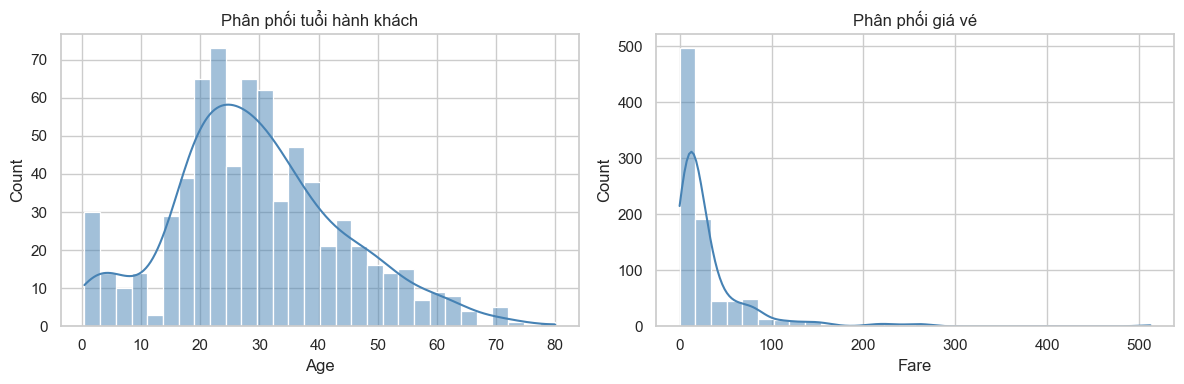

In [7]:
# TODO 5a: Histogram age & fare
...
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="age", kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối tuổi hành khách")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="fare", kde=True, bins=30, ax=axes[1], color="steelblue")
axes[1].set_title("Phân phối giá vé")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

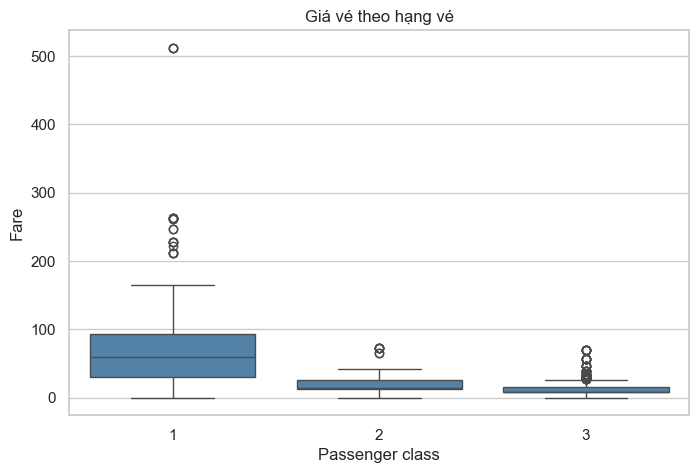

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
...
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="pclass", y="fare", color="steelblue")

plt.title("Giá vé theo hạng vé")
plt.xlabel("Passenger class")
plt.ylabel("Fare")
plt.show()

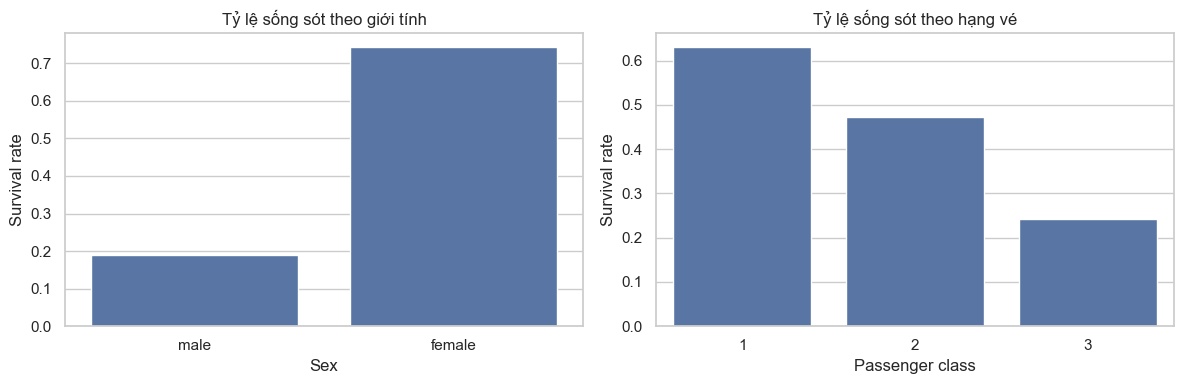

Tỷ lệ sống sót theo sex:


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Tỷ lệ sống sót theo pclass:


pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="sex", y="survived", ax=axes[0], errorbar=None)
axes[0].set_title("Tỷ lệ sống sót theo giới tính")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival rate")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], errorbar=None)
axes[1].set_title("Tỷ lệ sống sót theo hạng vé")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")

plt.tight_layout()
plt.show()

print("Tỷ lệ sống sót theo sex:")
display(df.groupby("sex")["survived"].mean())

print("Tỷ lệ sống sót theo pclass:")
display(df.groupby("pclass")["survived"].mean())


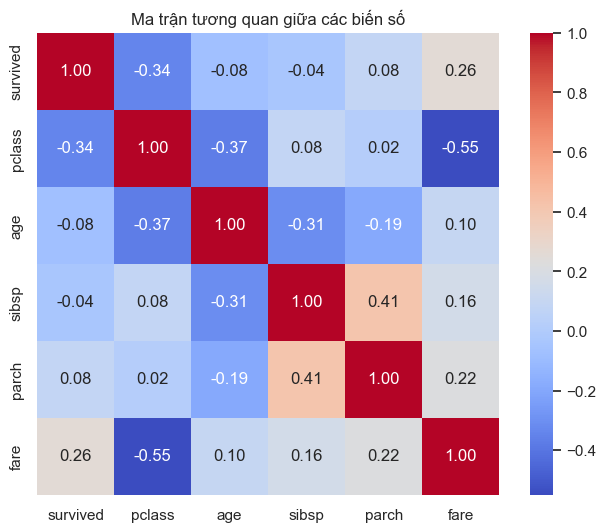

Tương quan với survived:


pclass   -0.338481
fare      0.257307
parch     0.081629
age      -0.077221
sibsp    -0.035322
Name: survived, dtype: float64

In [10]:
# TODO 5d: Heatmap correlation
...
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Ma trận tương quan giữa các biến số")
plt.show()

survived_corr = corr_matrix["survived"].drop("survived").sort_values(key=abs, ascending=False)

print("Tương quan với survived:")
display(survived_corr)

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: `age` tập trung nhiều ở nhóm người trẻ và trung niên. `fare` bị lệch phải rất rõ, nghĩa là đa số hành khách có giá vé thấp, nhưng vẫn có một số vé rất cao tạo thành đuôi dài bên phải.
- Boxplot: `fare` của hạng vé 1 thường cao hơn hạng 2 và hạng 3. Nhóm hạng 1 cũng có nhiều outlier giá vé cao, điều này hợp lý vì vé hạng nhất có thể đắt hơn nhiều.
- Bar survival: Tỷ lệ sống sót của nữ cao hơn nam khá rõ. Ngoài ra, hành khách hạng 1 có tỷ lệ sống sót cao hơn hạng 2 và hạng 3, cho thấy giới tính và hạng vé là hai đặc trưng rất đáng chú ý.
- Heatmap: Trong các biến số, `pclass` và `fare` có tương quan khá rõ với `survived`. `pclass` tương quan âm với `survived`, vì pclass càng lớn nghĩa là hạng vé càng thấp. Ngược lại, `fare` tương quan dương với `survived`, nghĩa là vé đắt hơn thường đi kèm khả năng sống sót cao hơn.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

val_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=val_size,
    random_state=42,
    stratify=y_tmp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTỷ lệ sống sót toàn bộ:", round(y.mean(), 4))
print("Tỷ lệ sống sót train:", round(y_train.mean(), 4))
print("Tỷ lệ sống sót val:", round(y_val.mean(), 4))
print("Tỷ lệ sống sót test:", round(y_test.mean(), 4))

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)

# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập

Train shape: (623, 7) (623,)
Val shape: (134, 7) (134,)
Test shape: (134, 7) (134,)

Tỷ lệ sống sót toàn bộ: 0.3838
Tỷ lệ sống sót train: 0.3836
Tỷ lệ sống sót val: 0.3881
Tỷ lệ sống sót test: 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

preprocess.fit(X_train)

X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

feature_names = preprocess.get_feature_names_out()

print("X_train_t shape:", X_train_t.shape)
print("X_val_t shape:", X_val_t.shape)
print("X_test_t shape:", X_test_t.shape)

print("\nTên cột sau biến đổi:")
print(feature_names)

X_train_t shape: (623, 10)
X_val_t shape: (134, 10)
X_test_t shape: (134, 10)

Tên cột sau biến đổi:
['num__age' 'num__sibsp' 'num__parch' 'num__fare' 'cat__sex_female'
 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q' 'cat__embarked_S'
 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*
Em chỉ `fit` pipeline trên tập train để tránh data leakage. Lý do là các bước như điền median, tìm mode, scale bằng median/IQR, hoặc học danh mục cho OneHotEncoder đều đang học thông tin từ dữ liệu.

Nếu fit trên toàn bộ dataset trước khi chia, thông tin của validation/test đã bị dùng trong quá trình tiền xử lý. Khi đó kết quả đánh giá có thể đẹp hơn thực tế. Cách đúng là học các tham số tiền xử lý từ train, rồi chỉ transform validation và test.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
...
class_ratio = df["survived"].value_counts(normalize=True).sort_index()
class_count = df["survived"].value_counts().sort_index()

print("Tỷ lệ hai lớp của survived:")
display(class_ratio)

print("Số lượng từng lớp:")
display(class_count)

Tỷ lệ hai lớp của survived:


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Số lượng từng lớp:


survived
0    549
1    342
Name: count, dtype: int64

**Trả lời 8:**

1. Biến `survived` có mất cân bằng nhẹ. Lớp 0 chiếm khoảng 61.6%, lớp 1 chiếm khoảng 38.4%. Đây chưa phải mất cân bằng cực đoan, nhưng cũng không hoàn toàn cân bằng.

2. Nếu chỉ nhìn Accuracy, ta có thể bị đánh lừa khi mô hình dự đoán thiên về lớp đông hơn. Ví dụ nếu mô hình đoán nhiều người là không sống sót thì accuracy vẫn có thể khá cao, nhưng mô hình lại bỏ sót nhiều người thật sự sống sót.

3. Với bài toán Titanic, em sẽ ưu tiên F1-score bên cạnh Accuracy. F1 cân bằng giữa Precision và Recall, phù hợp khi ta muốn đánh giá mô hình dự đoán lớp sống sót mà không chỉ thiên về một phía. Nếu bài toán đặt nặng việc tìm đúng người sống sót, em sẽ quan tâm thêm Recall cho lớp 1.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Trong các biến số, `pclass` và `fare` có liên hệ khá rõ với khả năng sống sót. `pclass` tương quan âm với `survived`, còn `fare` tương quan dương, cho thấy hành khách hạng vé cao hơn và trả giá vé cao hơn thường có cơ hội sống sót tốt hơn.

2. Cột thiếu dữ liệu đáng chú ý nhất sau khi bỏ các cột rò rỉ/dư thừa là `age`, thiếu khoảng 19.9%. Em chọn xử lý bằng median trong pipeline vì tuổi là biến số và median ít bị ảnh hưởng bởi outlier hơn mean.

3. Biến mục tiêu `survived` hơi mất cân bằng: lớp không sống sót nhiều hơn lớp sống sót. Vì vậy khi đánh giá mô hình, em không nên chỉ nhìn Accuracy mà nên xem thêm F1-score, Precision hoặc Recall.

4. Các biến số như `age`, `sibsp`, `parch`, `fare` cần impute và scaling. Đặc biệt `fare` có outlier nên em chọn RobustScaler. Các biến phân loại như `sex` và `embarked` cần được encoding bằng OneHotEncoder để mô hình có thể xử lý.

5. Điều em thấy thú vị là giới tính và hạng vé ảnh hưởng khá rõ đến tỷ lệ sống sót. Nữ có tỷ lệ sống sót cao hơn nam, và hành khách hạng 1 có tỷ lệ sống sót cao hơn hạng 3. Điều này cho thấy dữ liệu Titanic không chỉ là con số, mà còn phản ánh bối cảnh xã hội và cách ưu tiên cứu hộ lúc đó.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

,fare_original,standard_scaled,minmax_scaled,robust_scaled
0,7.2500,-0.502445,0.014151,-0.312011
1,71.2833,0.786845,0.139136,2.461242
2,7.9250,-0.488854,0.015469,-0.282777
3,53.1000,0.420730,0.103644,1.673732
4,8.0500,-0.486337,0.015713,-0.277363


Thống kê sau khi scale:


,fare_original,standard_scaled,minmax_scaled,robust_scaled
count,891.000000,8.910000e+02,891.000000,891.000000
mean,32.204208,3.987333e-18,0.062858,0.768745
std,49.693429,1.000562e+00,0.096995,2.152200
min,0.000000,-6.484217e-01,0.000000,-0.626005
25%,7.910400,-4.891482e-01,0.015440,-0.283409
50%,14.454200,-3.573909e-01,0.028213,0.000000
75%,31.000000,-2.424635e-02,0.060508,0.716591
max,512.329200,9.667167e+00,1.000000,21.562738


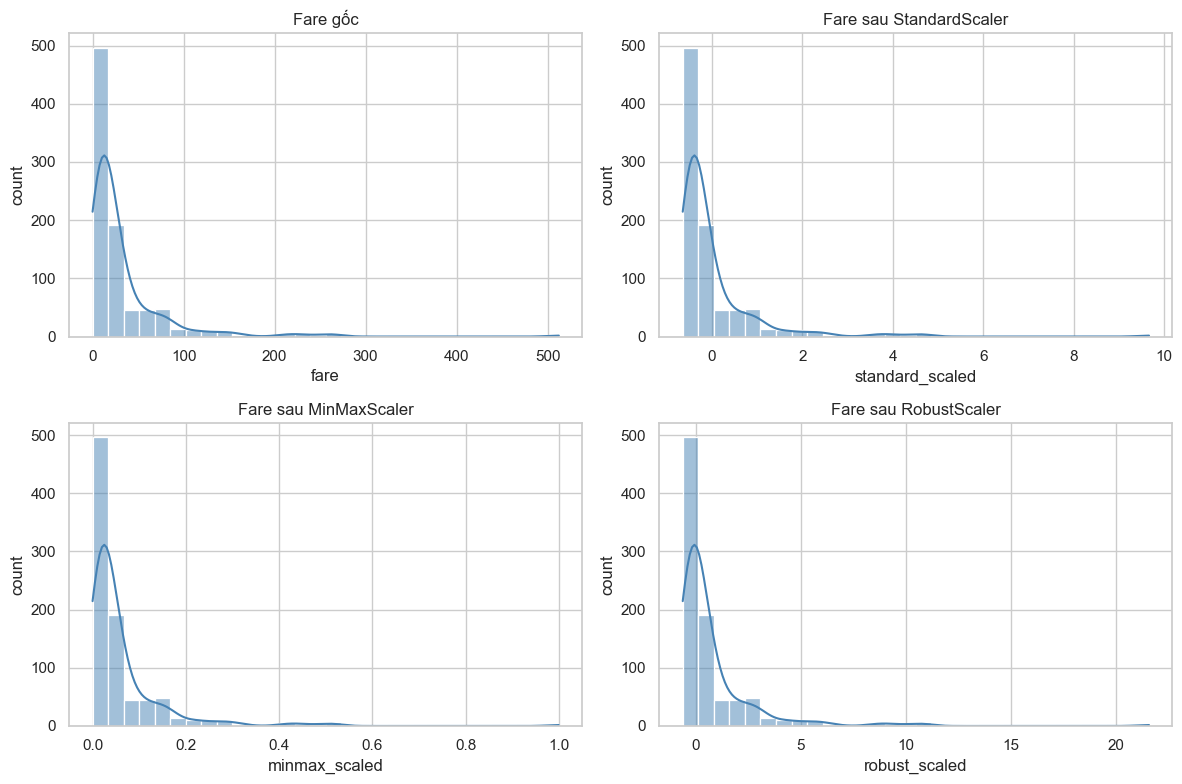

In [14]:
# (tùy chọn) code cho phần Bonus
...
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

fare_data = df[["fare"]].copy()

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

fare_scaled = pd.DataFrame({
    "fare_original": fare_data["fare"],
    "standard_scaled": standard_scaler.fit_transform(fare_data).ravel(),
    "minmax_scaled": minmax_scaler.fit_transform(fare_data).ravel(),
    "robust_scaled": robust_scaler.fit_transform(fare_data).ravel()
})

display(fare_scaled.head())

print("Thống kê sau khi scale:")
display(fare_scaled.describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(fare_scaled["fare_original"], kde=True, bins=30, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Fare gốc")
axes[0, 0].set_xlabel("fare")
axes[0, 0].set_ylabel("count")

sns.histplot(fare_scaled["standard_scaled"], kde=True, bins=30, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Fare sau StandardScaler")
axes[0, 1].set_xlabel("standard_scaled")
axes[0, 1].set_ylabel("count")

sns.histplot(fare_scaled["minmax_scaled"], kde=True, bins=30, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Fare sau MinMaxScaler")
axes[1, 0].set_xlabel("minmax_scaled")
axes[1, 0].set_ylabel("count")

sns.histplot(fare_scaled["robust_scaled"], kde=True, bins=30, ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Fare sau RobustScaler")
axes[1, 1].set_xlabel("robust_scaled")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

Em chọn so sánh các scaler trên biến `fare` vì biến này bị lệch phải khá mạnh và có nhiều outlier. Khi nhìn phân phối gốc, đa số giá vé nằm ở mức thấp, nhưng vẫn có một số giá vé rất cao làm đuôi bên phải kéo dài.

Sau khi dùng `StandardScaler`, dữ liệu được đưa về quanh trung bình 0, nhưng outlier vẫn ảnh hưởng khá nhiều vì StandardScaler dùng mean và standard deviation. Với `MinMaxScaler`, toàn bộ dữ liệu được ép vào khoảng từ 0 đến 1, nhưng do có vài giá vé rất cao nên phần lớn các điểm còn lại bị dồn sát về gần 0.

`RobustScaler` phù hợp hơn trong trường hợp này vì nó dùng median và IQR, nên ít bị ảnh hưởng bởi outlier hơn. Vì vậy với biến `fare`, em thấy RobustScaler là lựa chọn hợp lý nhất nếu sau này dùng dữ liệu này cho mô hình học máy.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
